In [1]:
import tensorflow as tf
import tensorboard
import matplotlib.pyplot as plt
import datetime

In [2]:
import tensorflow as tf

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

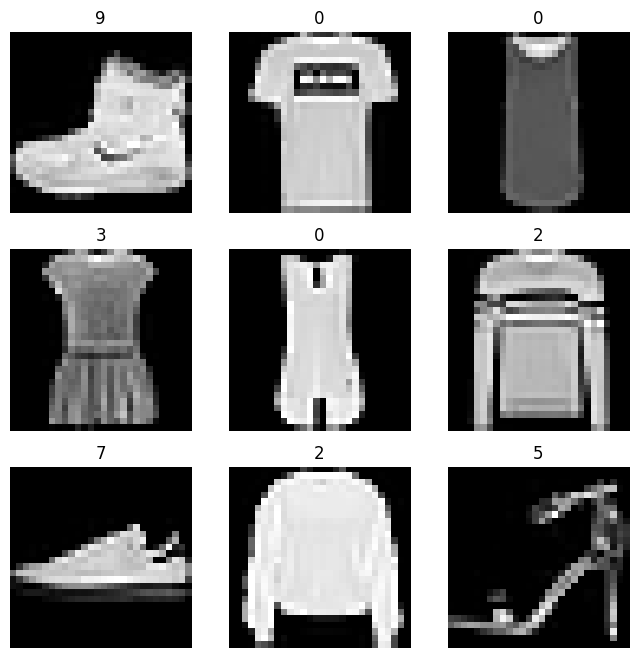

In [3]:
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")

plt.show()

In [4]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),

    tf.keras.layers.Dense(128, activation="relu"),

    tf.keras.layers.Dense(64, activation="relu"),

    tf.keras.layers.Dense(10, activation="softmax")
])

C:\Users\kunja\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [6]:
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

In [7]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=1
)

In [8]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test),
    callbacks=[tensorboard_callback]
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.8259 - loss: 0.4887 - val_accuracy: 0.8524 - val_loss: 0.4104
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8669 - loss: 0.3644 - val_accuracy: 0.8680 - val_loss: 0.3742
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.8773 - loss: 0.3312 - val_accuracy: 0.8669 - val_loss: 0.3664
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.8862 - loss: 0.3082 - val_accuracy: 0.8705 - val_loss: 0.3538
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.8912 - loss: 0.2923 - val_accuracy: 0.8774 - val_loss: 0.3391
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8971 - loss: 0.2767 - val_accuracy: 0.8704 - val_loss: 0.3540
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9000 - loss: 0.2654 - val_accuracy: 0.8770 - val_loss: 0.3573
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9046 - loss: 0

In [9]:
model.save("fashion_model.keras")

In [11]:
%load_ext tensorboard
%tensorboard --logdir logs/fit